In [48]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv("resultadosMejorados.csv")

In [22]:
df.head()

,Fecha,TipoDePrueba,Plataforma,Usuario,status
0,24/11/2025,Grupos,Gatito,NoQuique,Paso
1,20/11/2025,Grupos,Gatito,NoQuique,Paso
2,04/12/2025,Grupos,Gatito,NoQuique,Paso
3,11/12/2025,Grupos,Gatito,Quique,Paso
4,01/12/2025,Grupos,Gatito,Quique,Paso


In [23]:
df.describe()

,Fecha,TipoDePrueba,Plataforma,Usuario,status
count,300,300,300,300,300
unique,30,3,2,2,2
top,08/12/2025,Grupos,Joya,NoQuique,Paso
freq,17,100,157,156,211


In [24]:
pruebas = df.TipoDePrueba.unique()
pruebas

array(['Grupos', 'MultiplesGrupos', 'Confianza'], dtype=object)

# Codificaciones
Es Necesario Codificar la variable de status

In [25]:
df['status'] = df ['status'].map({'Fallo': 1, 'Paso':0})

# Generando Mascaras


In [26]:
list_mask = []
for element in pruebas:
    print(element)
    list_mask.append(df["TipoDePrueba"] == element)
list_mask

Grupos
MultiplesGrupos
Confianza


[0       True
 1       True
 2       True
 3       True
 4       True
        ...  
 295    False
 296    False
 297    False
 298    False
 299    False
 Name: TipoDePrueba, Length: 300, dtype: bool,
 0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 295    False
 296    False
 297    False
 298    False
 299    False
 Name: TipoDePrueba, Length: 300, dtype: bool,
 0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 295     True
 296     True
 297     True
 298     True
 299     True
 Name: TipoDePrueba, Length: 300, dtype: bool]

In [27]:
df[list_mask[0]]

,Fecha,TipoDePrueba,Plataforma,Usuario,status
0,24/11/2025,Grupos,Gatito,NoQuique,0
1,20/11/2025,Grupos,Gatito,NoQuique,0
2,04/12/2025,Grupos,Gatito,NoQuique,0
3,11/12/2025,Grupos,Gatito,Quique,0
4,01/12/2025,Grupos,Gatito,Quique,0
...,...,...,...,...,...
95,11/12/2025,Grupos,Gatito,Quique,0
96,26/11/2025,Grupos,Gatito,Quique,0
97,12/12/2025,Grupos,Joya,NoQuique,1
98,10/12/2025,Grupos,Gatito,Quique,1


# Calcular la tasa de fallo Failure rate
TasaDeFallo = Total Fallos/ Total Ejecuciones

In [99]:
df[list_mask[0]]["TipoDePrueba"][0]

'Grupos'

In [ ]:
priorityDf = pd.DataFrame(columns=["Prueba", "Fallos", "Pasados", "TasaDeFallo"])
for element in range(len(list_mask)):
    #print(f'Prueba: {df[list_mask[element]]["TipoDePrueba"].values[0]}')
    prueba = df[list_mask[element]]["TipoDePrueba"].values[0]
    print(f'Prueba: {prueba}')
    totalFallos = df[list_mask[element]].status.sum()
    totalPasados = len(df[list_mask[element]]) - totalFallos
    TasaDeFallo = (totalFallos/(totalFallos+totalPasados))*100
    print(f'Fallados: {totalFallos}')
    print(f'Pasados: {totalPasados}')
    print(f'TasaDeFallo: {TasaDeFallo}%')
    newRow = {"Prueba":prueba, "Fallos": totalFallos, "Pasados": totalPasados, "TasaDeFallo":TasaDeFallo}
    df_new_Row = pd.DataFrame([newRow])
    priorityDf = pd.concat([priorityDf, df_new_Row], ignore_index=True)

Prueba: Grupos
Fallados: 25
Pasados: 75
TasaDeFallo: 25.0%
Prueba: MultiplesGrupos
Fallados: 33
Pasados: 67
TasaDeFallo: 33.0%
Prueba: Confianza
Fallados: 31
Pasados: 69
TasaDeFallo: 31.0%


C:\Users\oso_e\AppData\Local\Temp\ipykernel_24352\2925483429.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  priorityDf = pd.concat([priorityDf, df_new_Row], ignore_index=True)


In [115]:
priorityDf

,Prueba,Fallos,Pasados,TasaDeFallo
0,Grupos,25,75,25.0
1,MultiplesGrupos,33,67,33.0
2,Confianza,31,69,31.0


# Ordenar


In [118]:
priorityDf = priorityDf.sort_values(by="TasaDeFallo", ascending=False).reset_index(drop= True)
priorityDf

,Prueba,Fallos,Pasados,TasaDeFallo
0,MultiplesGrupos,33,67,33.0
1,Confianza,31,69,31.0
2,Grupos,25,75,25.0


Esta simulacion, serviria para correr primero las pruebas que estan fallando

# Visualizacion

In [119]:
import matplotlib.pyplot as plt

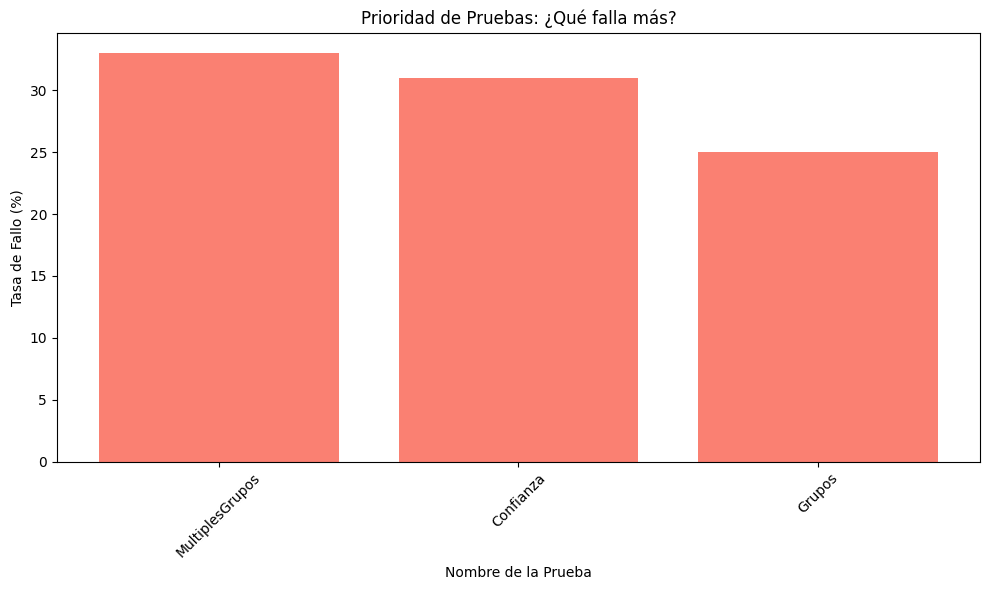

In [120]:
plt.figure(figsize=(10, 6))
plt.bar(priorityDf['Prueba'], priorityDf['TasaDeFallo'], color='salmon')

plt.title('Prioridad de Pruebas: ¿Qué falla más?')
plt.xlabel('Nombre de la Prueba')
plt.ylabel('Tasa de Fallo (%)')
plt.xticks(rotation=45) # Rota los nombres para que se lean bien
plt.tight_layout()
plt.show()